# Spatial metacell comparison — cell-type purity vs. niche purity

Loads the runs produced by `train_scproto_affinity_comparison.ipynb`
(`arbf`, `mean_product`, `banksy0.5`) plus a SEACells (PCA) baseline, and computes,
**for every cell type** (not just tumor cells), two per-cell metrics from each
model's saved `cell_assignments.csv`:

- `celltype_purity(i)` = fraction of cell *i*'s metacell sharing its cell type
- `niche_purity(i)`    = fraction of cell *i*'s metacell sharing **both** its cell
  type *and* its niche

`niche_purity <= celltype_purity` always (same denominator, stricter numerator) —
a metacell can't score well on niche purity without also grouping cell types well.
See `all_celltype_niche_purity()` in `spatial_immune_task.py` for the exact formula.

This notebook does **not** train or load full models — it only reads the
`cell_assignments.csv` file each run already saved to disk, joined with niche
labels. No GPU needed here.

Outputs:
1. **Table** — cell-type purity, rows = model, cols = cell type.
2. **Heatmap** — one panel per model, rows = cell type, cols = niche, color = niche purity.
3. **Trade-off scatter** — one dot per (model, cell type): x = celltype purity, y = niche purity.

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


## Config

`DS_ID` matches `train_scproto_affinity_comparison.py`. `NICHE_KEY` is `niches_2D`
here by choice — it doesn't need to match what training's own niche_key was (the
built-in tumor-niche eval during training used `niches_3D`); this notebook scores
purity against whichever ground-truth niche column you point it at, joined in from
the source h5ad if it's not already in the saved `cell_assignments.csv`.

In [ ]:
DS_ID = 's28nsc'
NICHE_KEY = 'niches_2D'
CELLTYPE_KEY = 'celltypes'
MIN_CELLS = 20  # drop cell types with fewer cells than this

GRAPH_DIR = os.path.join(os.environ['CODE_DIR'], 'graphs')
os.makedirs(GRAPH_DIR, exist_ok=True)

# keyword -> display name. Keywords are matched as substrings against each run's
# auto-generated model directory name (see _resolve_run_dir in paper_figures.py).
# 'seacell' is special-cased to the SEACells model dir directly.
#
# NOTE: generate_model_name() (interpretable_ssl/model_name.py:39) truncates every
# string-valued hyperparameter to its first 4 characters when building the run
# directory name. affinity_type='mean_product' and 'banksy0.5' therefore show up in
# the actual directory as 'aff-mean' and 'aff-bank', not the full string — match on
# the truncated form (prefixed with 'aff-' to avoid accidentally matching an
# unrelated substring elsewhere in the directory name).
MODEL_KEYWORDS = {
    'aff-arbf': 'scProto + PCA only',
    'aff-mean': 'scProto + PCA product',
    'aff-bank': 'scProto + BANKSY affinity',
    'seacell':  'SEACells (PCA)',
}

## Ensure the SEACells baseline exists

`train_seacell` skips training and returns immediately if a saved SEACells run is
already found — safe to call every time.

In [ ]:
train_seacell(DS_ID, mode='train', build_kernel_on='X_pca')

## 1. Cell-type purity table

Rows = model, columns = cell type. Each cell is `median [Q1, Q3]` of the per-cell
fraction of that cell's metacell sharing its cell type (per-cell value, conditioned on
true label — see `all_celltype_niche_purity()`; this is *not* the same formula as the
top-level `purity` column in the training notebook's `metrics_df`, which averages
per-metacell instead of per-cell — the two numbers are expected to disagree).

Using median/IQR instead of mean ± std deliberately: per-cell purity is often bimodal
(some cells land in a small near-pure metacell, others in a large mixed one), which
makes std larger than the mean and a mean ± std summary misleading. Pass
`stat='mean_std'` to fig_celltype_purity_table if you want that version instead.

In [ ]:
median_ct, q25_ct, q75_ct = fig_celltype_purity_table(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='celltype_purity',
)
format_purity_table(median_ct, q25_ct, q75_ct)

celltype,Alveolar cells,B cells,Basal epithelial cells,Cycling immune cells,Cytotoxic T cells,Dendritic cells,Fibroblasts,Lymphatic endothelial cells,Macrophages,Mast cells,Monocytes,Pericytes,Plasma cells,Regulatory T cells,Respiratory epithelium,Smooth muscle cells,Tumor cells,Vascular endothelium
scProto + PCA only,"0.06 [0.01, 0.06]","0.00 [0.00, 0.01]","0.22 [0.22, 0.22]","0.02 [0.02, 0.04]","0.13 [0.07, 0.35]","0.10 [0.10, 0.10]","0.47 [0.26, 0.57]","0.05 [0.02, 0.05]","0.14 [0.12, 0.62]","0.01 [0.01, 0.02]","0.04 [0.03, 0.08]","0.18 [0.18, 0.18]","0.14 [0.14, 0.14]","0.02 [0.02, 0.05]","0.70 [0.70, 0.70]","0.20 [0.20, 0.20]","0.78 [0.78, 0.86]","0.17 [0.14, 0.17]"
scProto + PCA product,"0.07 [0.04, 0.07]","0.01 [0.00, 0.01]","0.22 [0.22, 0.22]","0.05 [0.04, 0.05]","0.28 [0.13, 0.41]","0.13 [0.13, 0.13]","0.83 [0.29, 0.93]","0.08 [0.02, 0.08]","0.39 [0.20, 0.79]","0.02 [0.01, 0.03]","0.17 [0.03, 0.17]","0.29 [0.29, 0.29]","0.19 [0.05, 0.19]","0.04 [0.03, 0.06]","0.72 [0.72, 0.72]","0.25 [0.25, 0.25]","0.99 [0.83, 0.99]","0.28 [0.15, 0.28]"
scProto + BANKSY affinity,"0.21 [0.02, 0.21]","0.01 [0.01, 0.02]","0.67 [0.11, 1.00]","0.05 [0.04, 0.07]","0.71 [0.27, 0.71]","0.09 [0.02, 0.09]","0.87 [0.70, 0.97]","0.21 [0.02, 0.21]","0.63 [0.61, 0.84]","0.03 [0.01, 0.03]","0.19 [0.09, 0.19]","0.44 [0.44, 0.44]","0.90 [0.90, 0.90]","0.13 [0.02, 0.13]","0.88 [0.88, 0.88]","0.16 [0.16, 0.20]","0.99 [0.94, 1.00]","0.73 [0.73, 0.73]"
SEACells (PCA),"0.86 [0.29, 0.94]","0.18 [0.02, 0.82]","0.51 [0.08, 0.87]","0.10 [0.04, 0.28]","0.67 [0.38, 0.84]","0.61 [0.09, 0.91]","0.94 [0.78, 0.98]","0.75 [0.11, 1.00]","0.83 [0.65, 0.95]","0.06 [0.02, 0.75]","0.48 [0.08, 0.77]","0.81 [0.23, 0.90]","0.76 [0.45, 0.96]","0.24 [0.06, 0.41]","0.93 [0.86, 0.96]","0.72 [0.11, 0.89]","1.00 [0.97, 1.00]","0.94 [0.56, 1.00]"


In [ ]:
# Same table, color-coded by median value for a quick visual scan across models.
median_ct.round(3).style.background_gradient(cmap='YlGnBu', vmin=0, vmax=1)

celltype,Alveolar cells,B cells,Basal epithelial cells,Cycling immune cells,Cytotoxic T cells,Dendritic cells,Fibroblasts,Lymphatic endothelial cells,Macrophages,Mast cells,Monocytes,Pericytes,Plasma cells,Regulatory T cells,Respiratory epithelium,Smooth muscle cells,Tumor cells,Vascular endothelium
scProto + PCA only,0.058000,0.004000,0.216000,0.024000,0.133000,0.103000,0.467000,0.051000,0.142000,0.012000,0.038000,0.178000,0.135000,0.019000,0.699000,0.196000,0.779000,0.167000
scProto + PCA product,0.071000,0.011000,0.216000,0.051000,0.279000,0.130000,0.828000,0.077000,0.391000,0.018000,0.167000,0.286000,0.192000,0.039000,0.724000,0.252000,0.991000,0.284000
scProto + BANKSY affinity,0.214000,0.009000,0.667000,0.047000,0.710000,0.086000,0.868000,0.210000,0.629000,0.027000,0.186000,0.444000,0.904000,0.130000,0.875000,0.156000,0.990000,0.728000
SEACells (PCA),0.861000,0.183000,0.514000,0.099000,0.667000,0.607000,0.945000,0.750000,0.834000,0.059000,0.475000,0.812000,0.760000,0.239000,0.925000,0.725000,1.000000,0.935000


## 2. Niche purity heatmap — one panel per model

Rows = cell type, columns = niche, plus an "All niches" summary column (aggregated
across that cell type's own niches — the coarse per-cell-type number). Color = median
niche purity by default (`stat='median_iqr'`, same reasoning as table 1 — niche_purity
inherits celltype_purity's bimodality, so median is the more honest central value); each
cell is annotated `median [Q1, Q3]`. The joint celltype-and-niche metric means this
can't be inflated by a model that scatters cell types but happens to keep a same-type
fragment in one niche.

If the two-line annotation feels dense across all 18 cell types, pass `annot=False`
for a color-only view, or `cell_types=[...]` to restrict to a handful of key cell types
for a paper-figure-style look (see `fig_ct_niche_heatmap`'s curated 6-cell-type figure).

(celltype, niche) combinations with **zero ground-truth cells** render as plain
white — distinct from a low-but-measured value, which still gets a color.

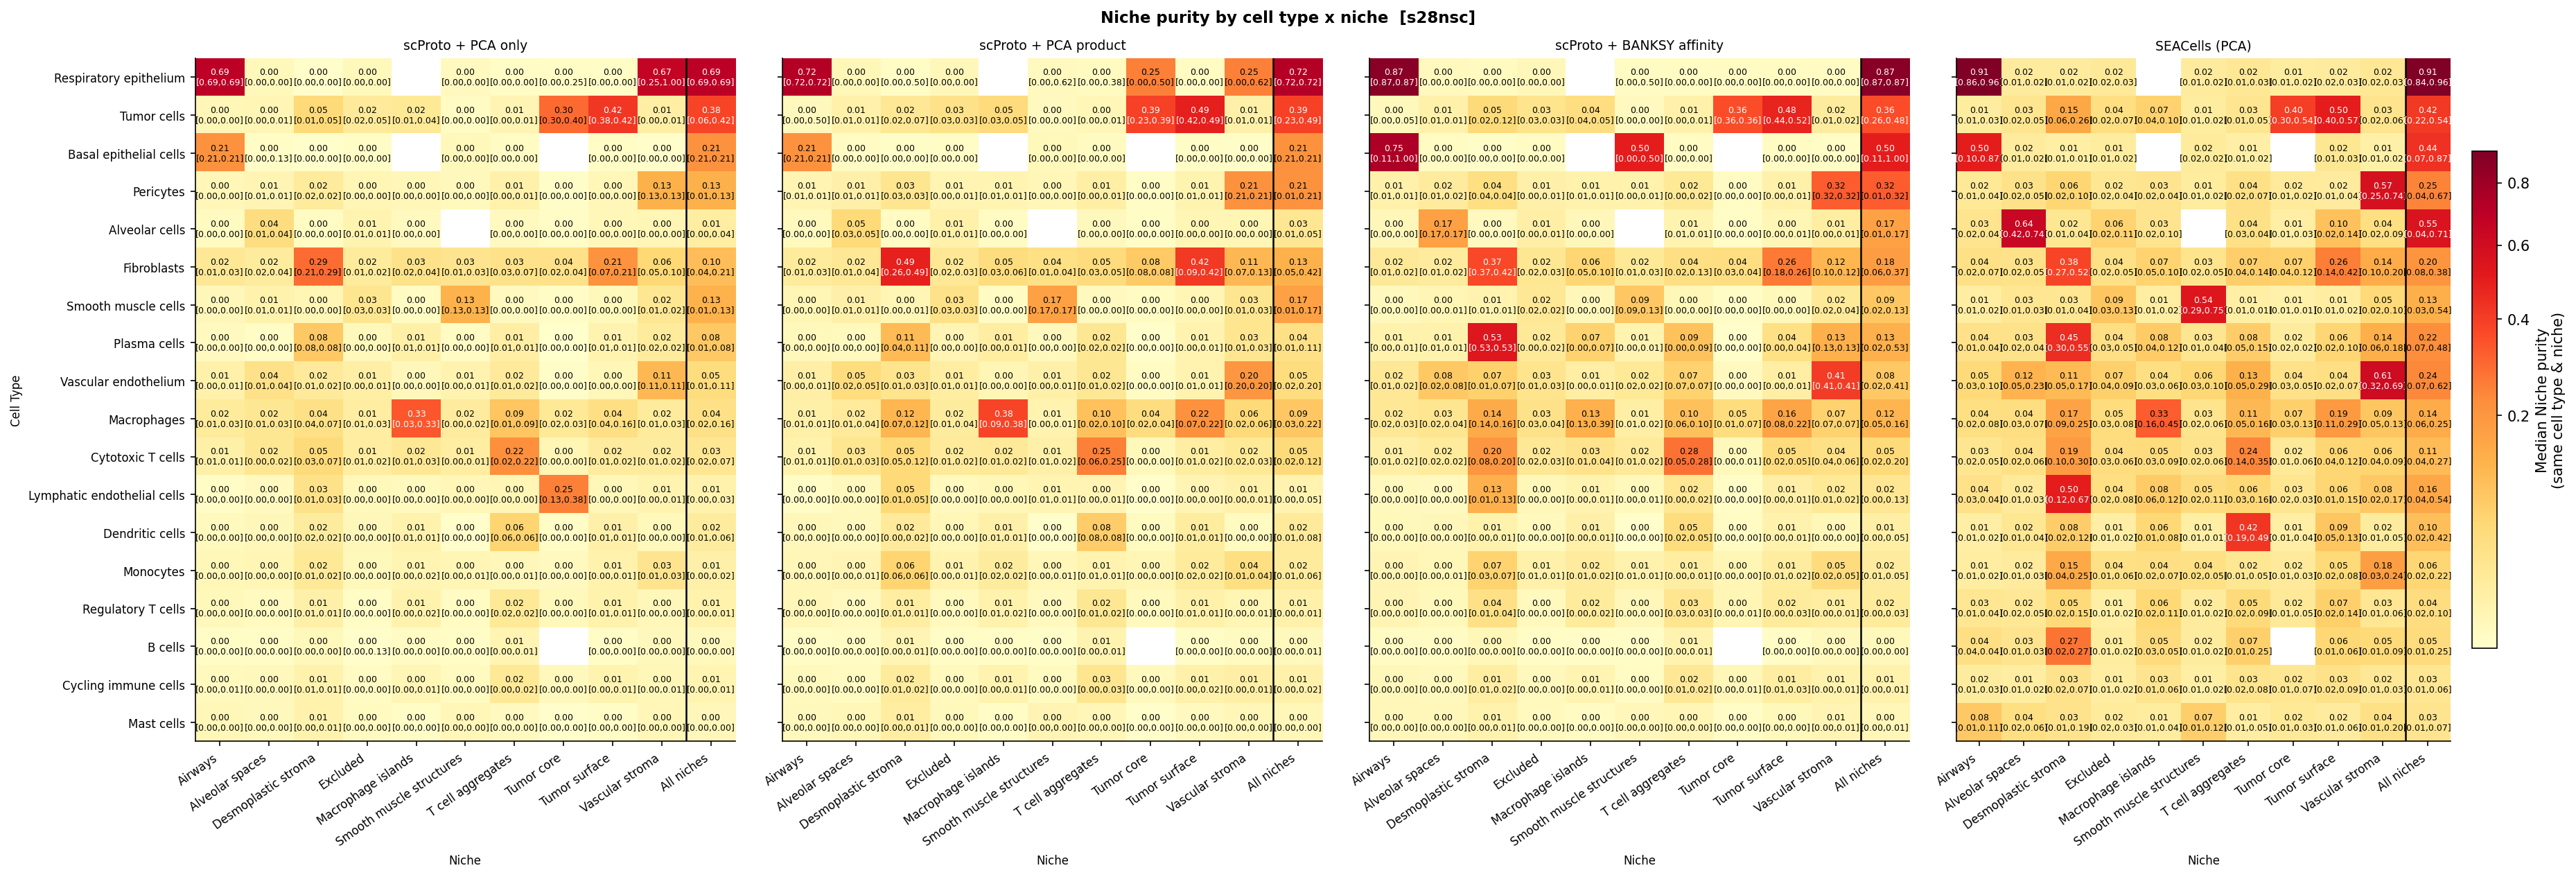

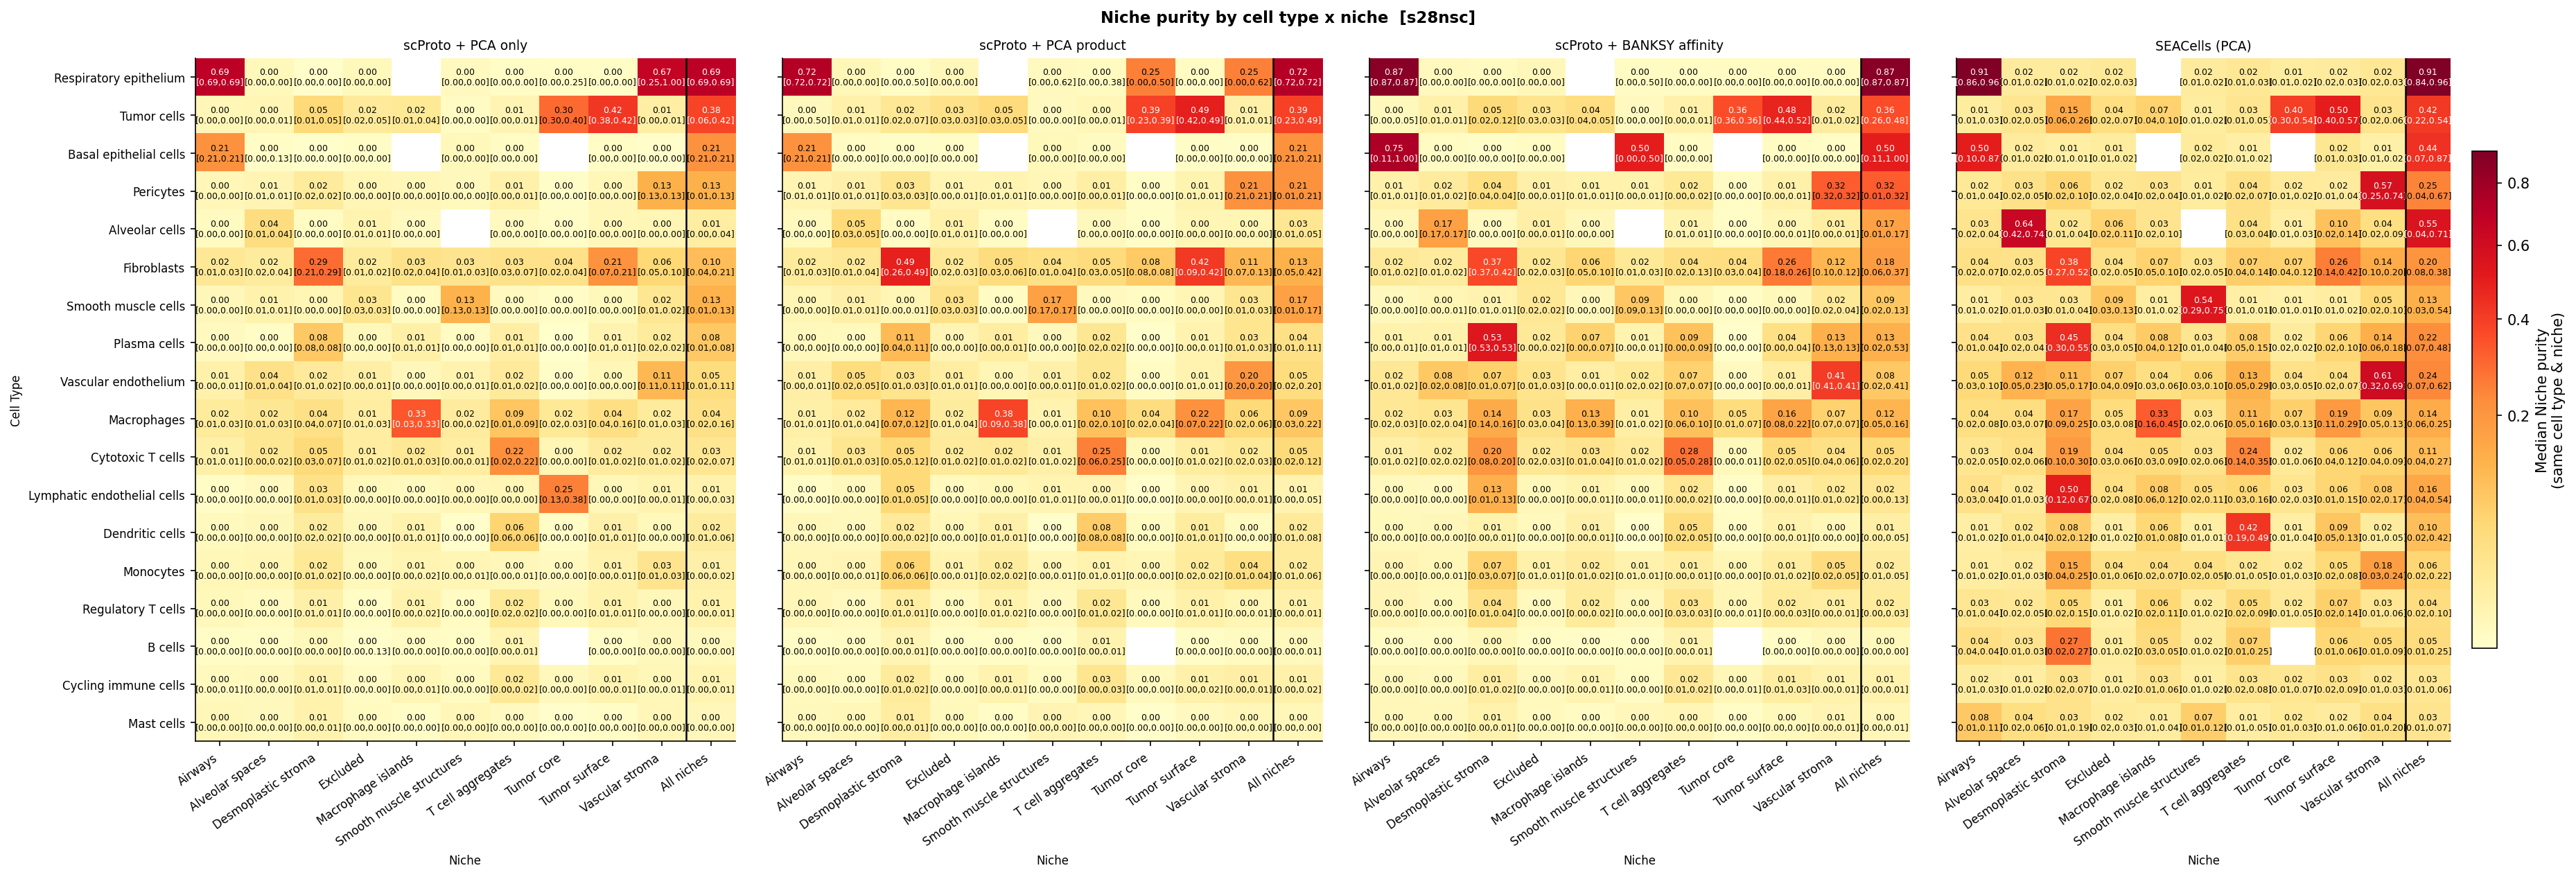

In [ ]:
fig_all_celltype_niche_heatmap(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='niche_purity',
    save_path=os.path.join(GRAPH_DIR, 'spatial_celltype_niche_heatmap.pdf'),
)

## 2b. Cell-type purity heatmap — same grid, "same cell type" only (niche not required)

Same rows/columns as above, but color = cell-type purity **alone**: of cells with this
type sitting in this niche, what fraction of their metacell shares just the cell type,
regardless of which niche those metacell-mates are actually from. Not every niche shapes
a cell type's expression the same amount, so this can be high in a niche even where the
niche_purity heatmap above is low — the gap between the two heatmaps for the same cell
(same cell type well-grouped, but niche_purity low) is exactly where the model groups
the cell type but doesn't resolve that specific niche.

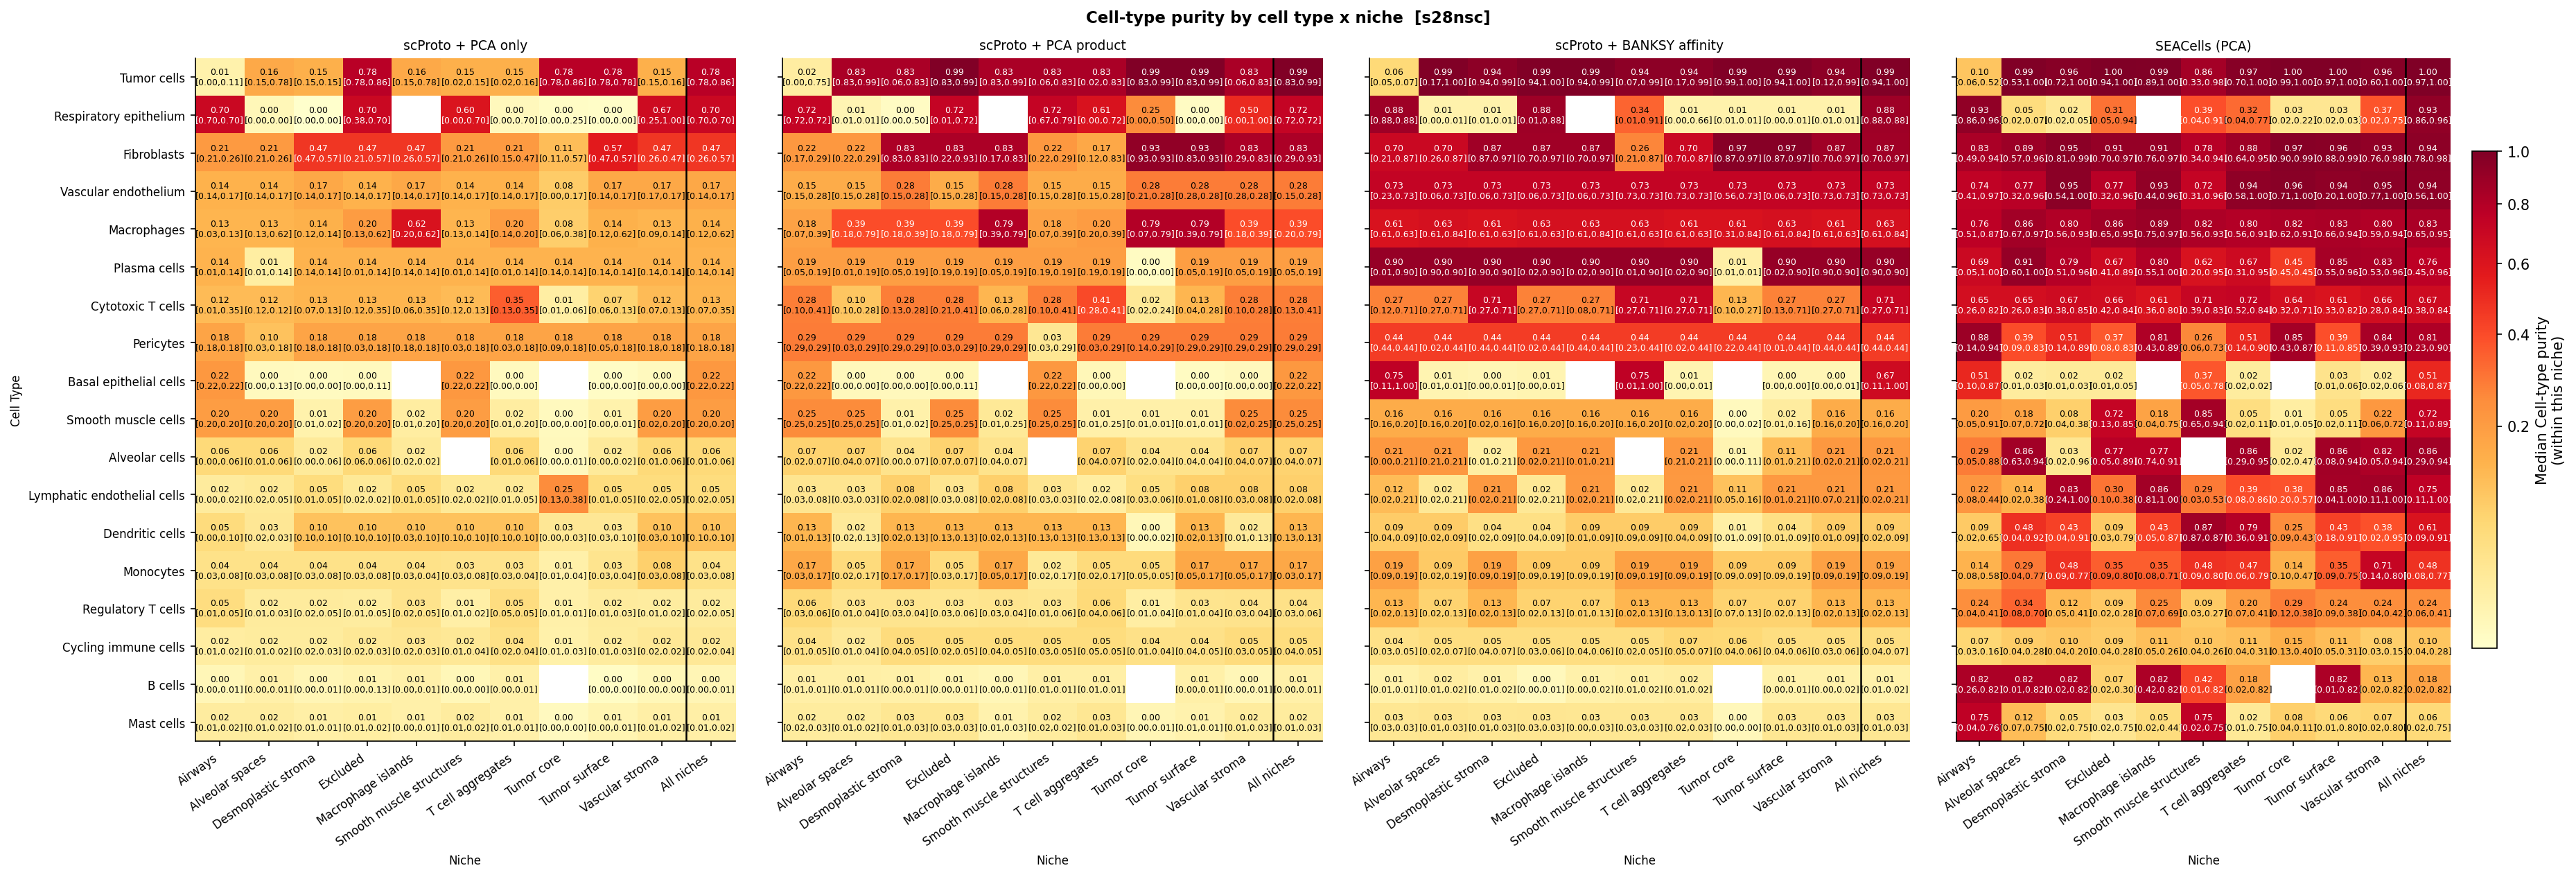

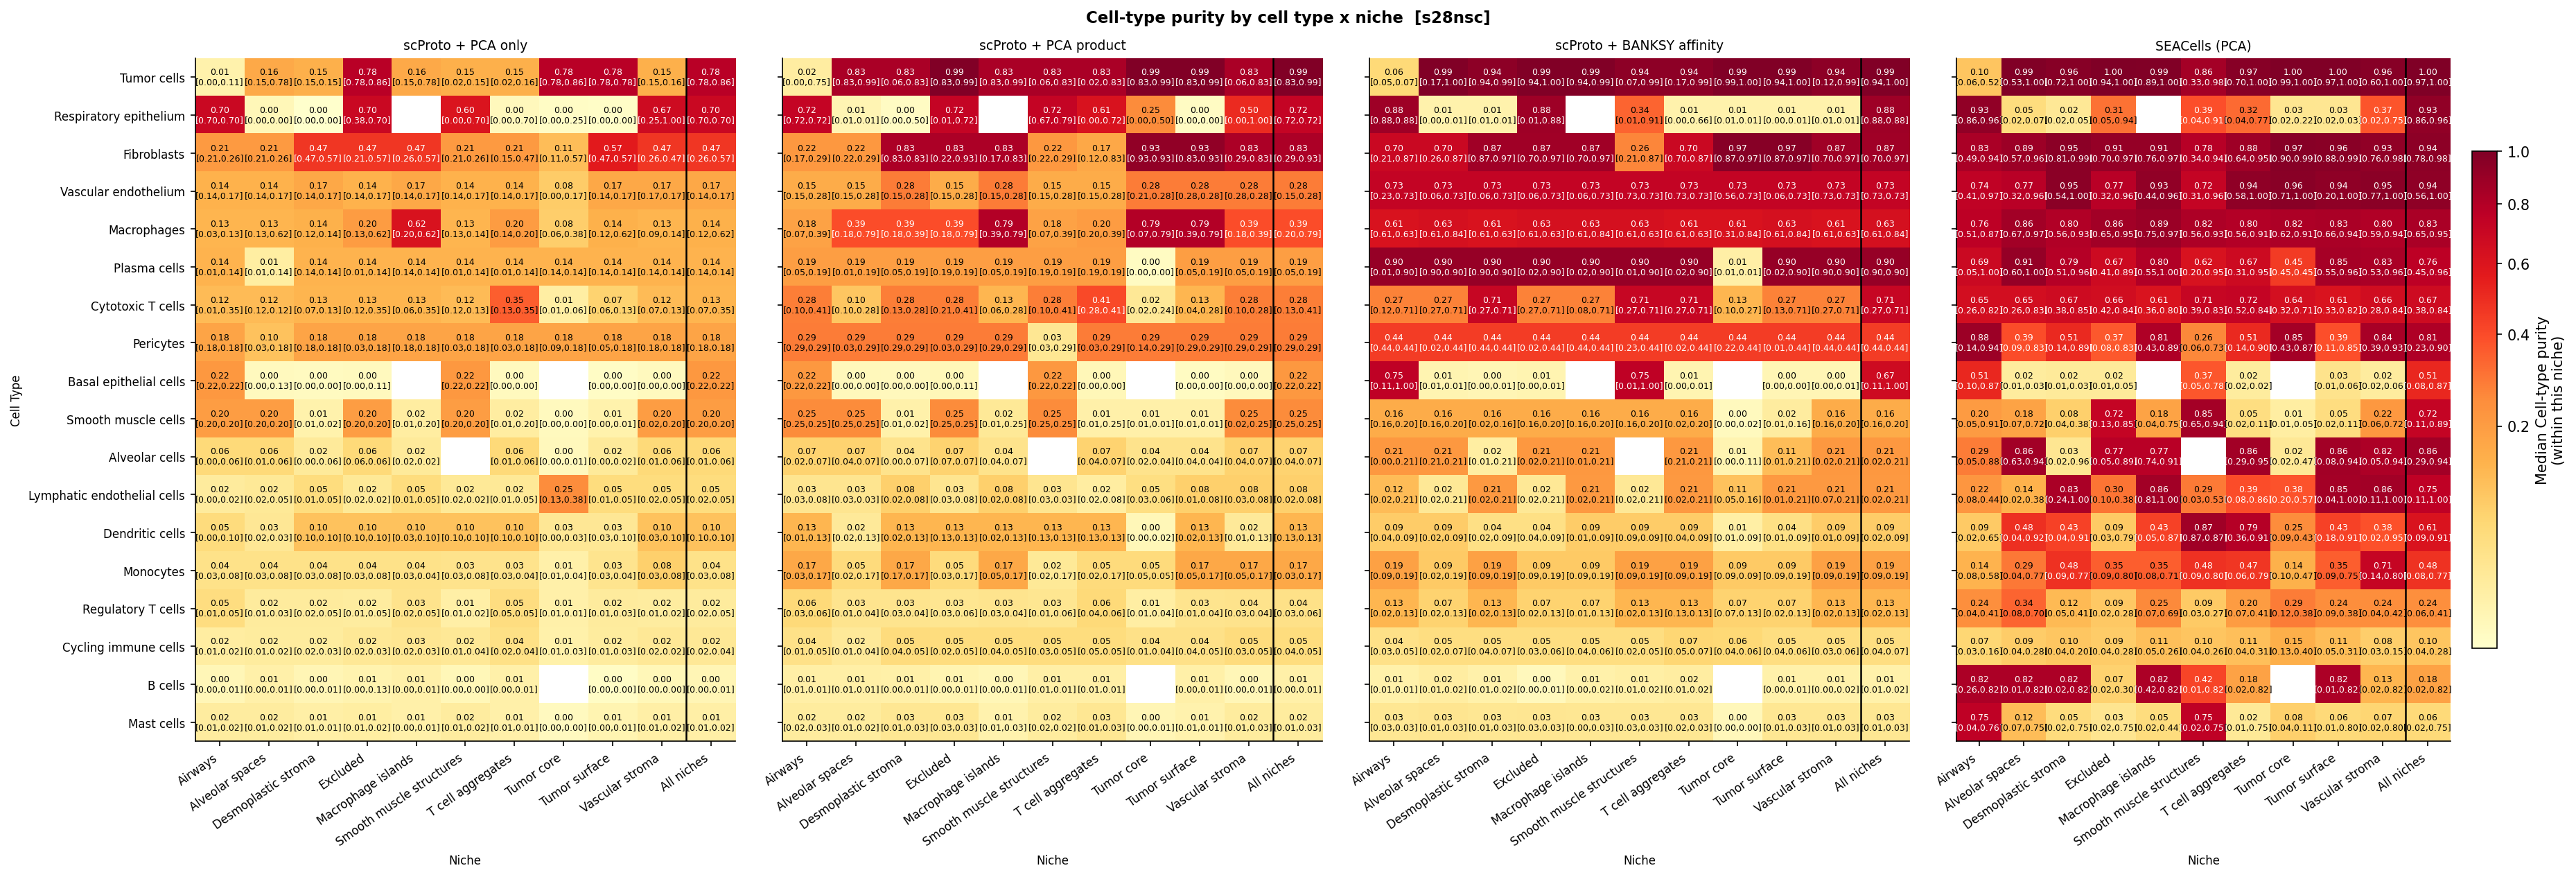

In [ ]:
fig_all_celltype_niche_heatmap(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='celltype_purity',
    save_path=os.path.join(GRAPH_DIR, 'spatial_celltype_heatmap.pdf'),
)

## 2b-ii. Niche purity conditional on cell type — the third piece of the decomposition

`niche_purity(i) = celltype_purity(i) * niche_given_celltype_purity(i)`, exactly, per
cell (only approximately once aggregated into a median/mean per grid cell, since neither
operation distributes over multiplication). This heatmap is the second factor: of a
cell's same-*type* metacell-mates only, what fraction are also in its niche — i.e. niche
resolution *given that* cell-type grouping already happened, isolated from whether the
cell type was grouped well in the first place.

Read the three heatmaps together to diagnose a low value in section 2: if celltype_purity
(2b) is already low for that cell, that's the bottleneck; if celltype_purity is fine but
this one is low, the model groups the cell type but doesn't separate this specific niche
within it — the more interesting biological case, and the direct answer to "does niche
affect this cell type's state." Cells from metacells with fewer than 3 same-type members
are masked out here (`min_same_type_count` in all_celltype_niche_purity) since the ratio
is a coin flip at that sample size — see conversation above for why.

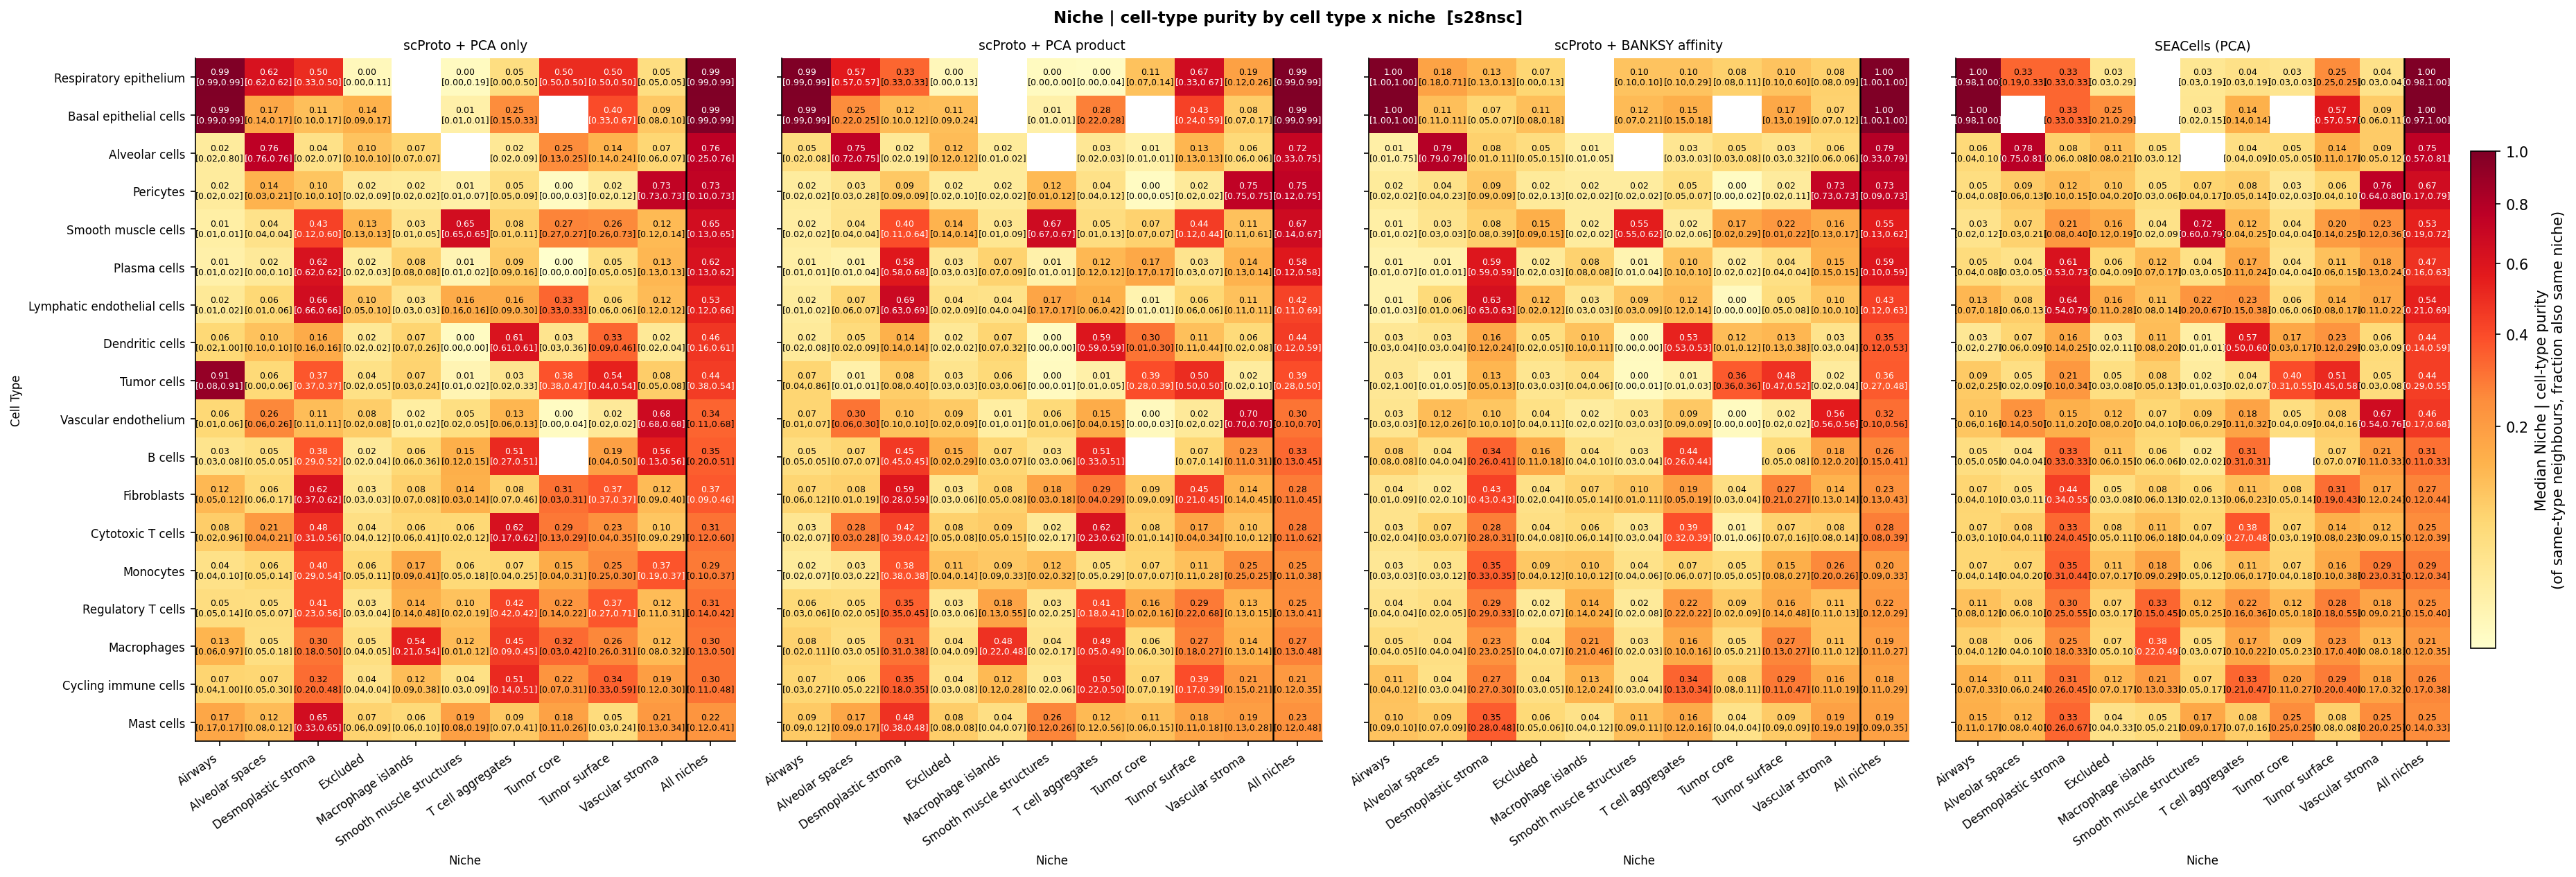

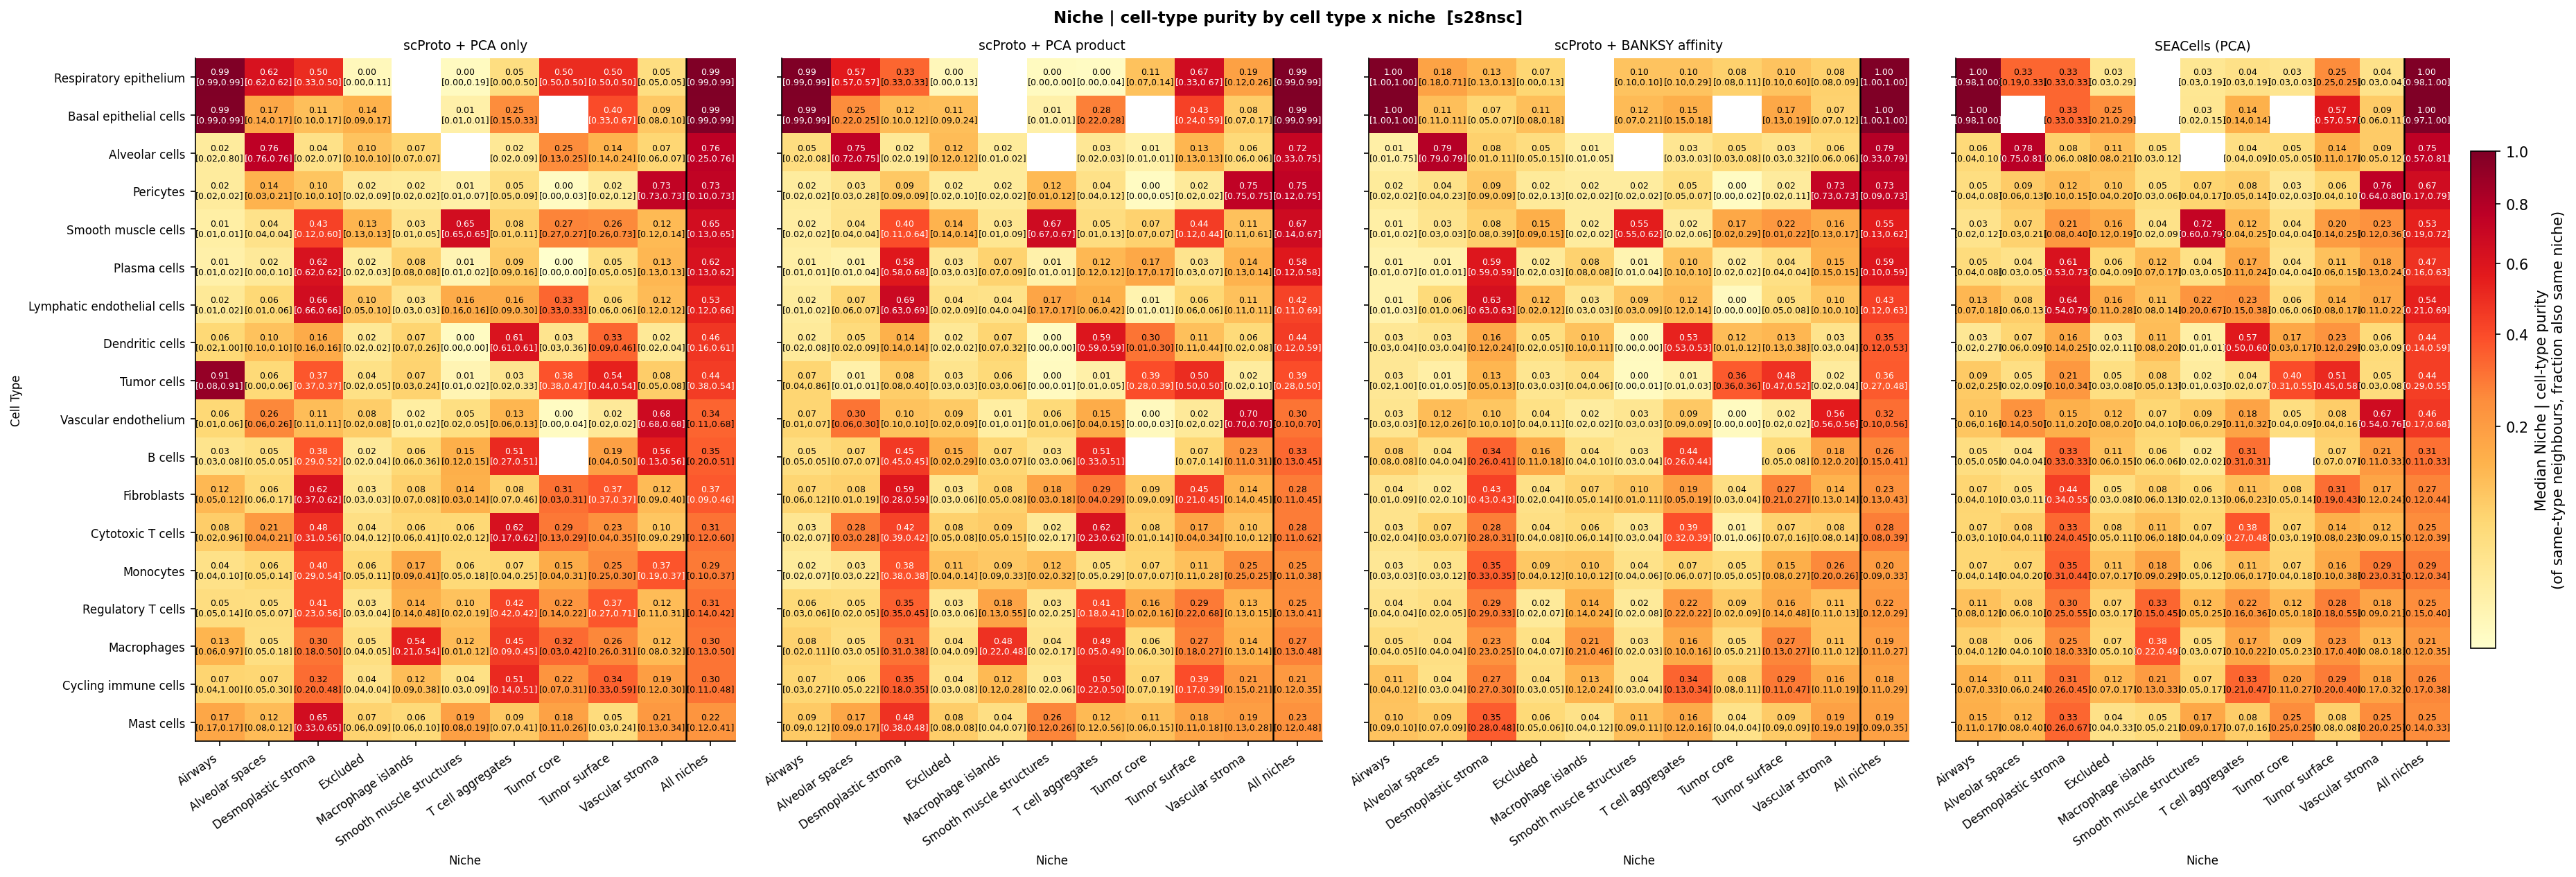

In [ ]:
fig_all_celltype_niche_heatmap(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='niche_given_celltype_purity',
    save_path=os.path.join(GRAPH_DIR, 'spatial_niche_given_celltype_heatmap.pdf'),
)

## 2c. Difference heatmap — where does spatial affinity actually beat the PCA-only baseline?

Absolute niche_purity is low almost everywhere (it requires matching BOTH cell type and
niche in the same metacell, and with ~9 niches any single one is a small target — see the
markdown above table 1 for why celltype_purity itself is already modest for common cell
types, before niche_purity multiplies that down further). That makes the absolute heatmaps
above a bad tool for finding *specific* (cell type, niche) pairs where "niche shapes this
cell type's expression, and this model captures it" — everything looks pale.

This instead plots (model − PCA-only baseline) per (cell type, niche) cell, diverging
color: red = this model resolves that pair better than the transcriptomics-only baseline,
blue = worse. Cells backed by fewer than `min_n` ground-truth samples in either model are
greyed out (a difference from 3 cells isn't a finding). The printed list below each panel
is the concrete candidate list for "look at this pair — PCA-only mixes niches here, but
with spatial affinity we separate them" — cross-reference the top hits against what's
actually known biologically for that cell type before claiming the effect.

In [ ]:
fig_celltype_niche_heatmap_diff(
    DS_ID, MODEL_KEYWORDS, reference='aff-arbf',
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='niche_purity', min_n=5,
    save_path=os.path.join(GRAPH_DIR, 'spatial_niche_purity_diff_heatmap.pdf'),
)

No data loaded for reference 'seacell'.


## 3. Trade-off trend — cell-type purity vs. niche purity, per model

Small dots, one per (model, cell type), colored by model, no per-point labels — deliberately
built to show the overall trend rather than let you track individual cell types. The solid
line per model is a linear best fit across that model's cell-type dots.

The dashed diagonal is the structural upper bound (niche purity <= cell-type purity) — a
trend line hugging the diagonal means that model separates niches almost as well as it
groups cell types; a trend line well below the diagonal means it groups cell types but
scatters niches within them.

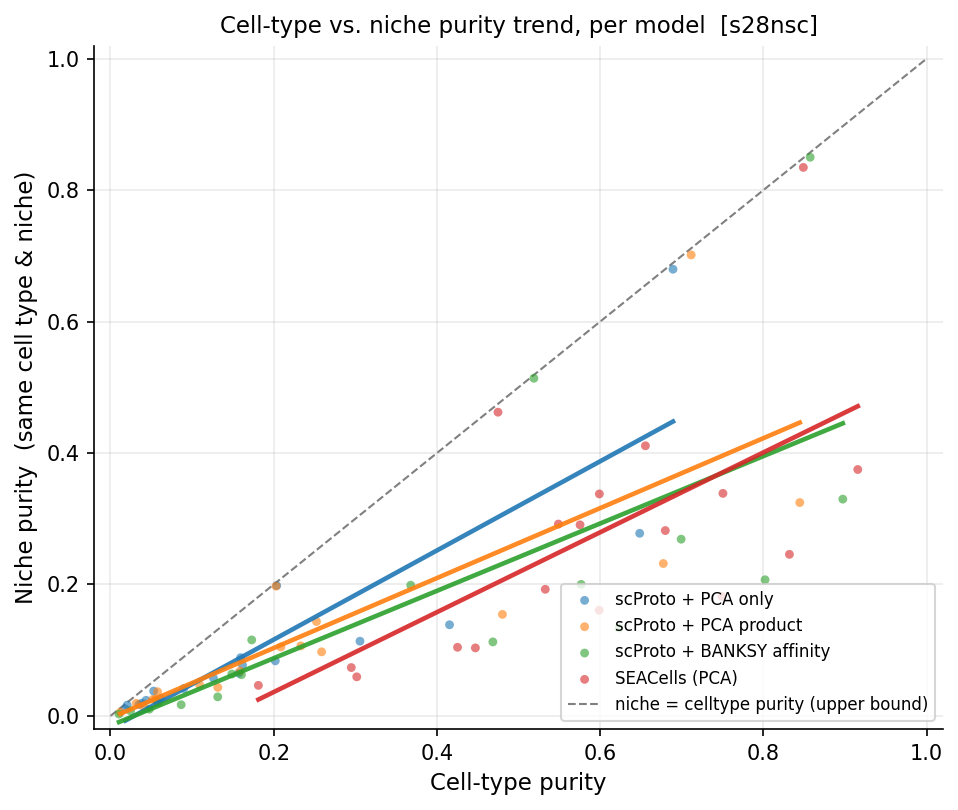

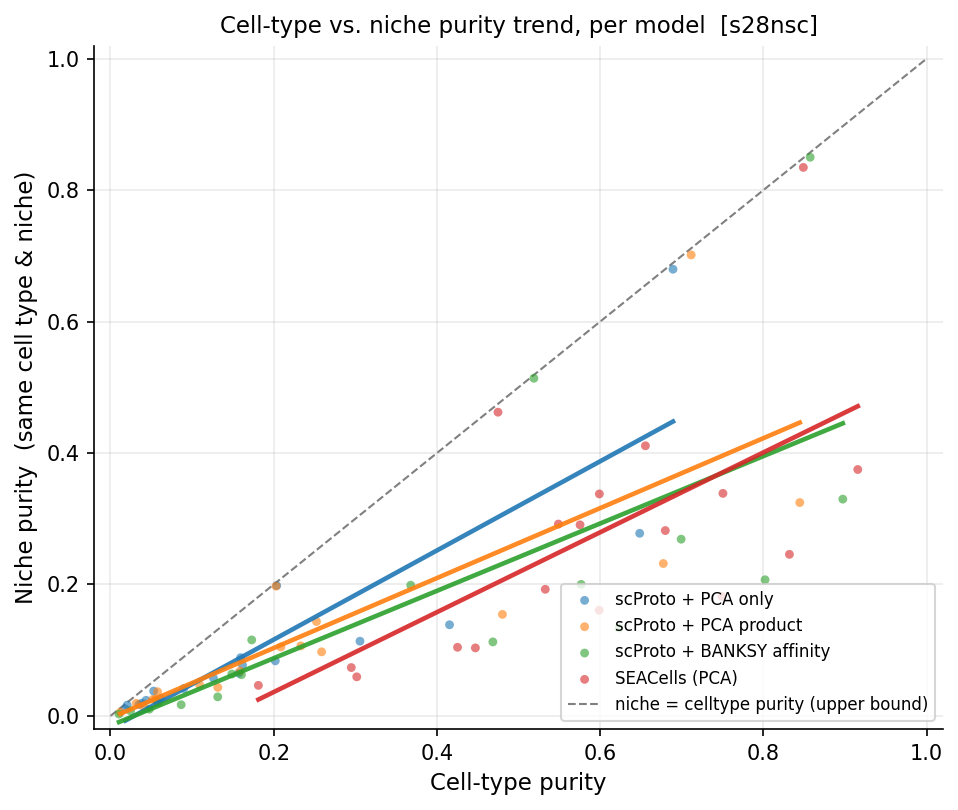

In [ ]:
fig_celltype_niche_tradeoff(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS,
    save_path=os.path.join(GRAPH_DIR, 'spatial_celltype_niche_tradeoff.pdf'),
)

## 4. Niche purity summary table (collapses the heatmap's niche axis)

Same `median [Q1, Q3]` format as table 1, but for niche purity averaged across each cell
type's own niches — the coarse "how well does this model resolve niches for this cell
type overall" number, alongside table 1's "how well does it group the cell type at all".

In [ ]:
median_niche, q25_niche, q75_niche = fig_celltype_purity_table(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='niche_purity',
)
format_purity_table(median_niche, q25_niche, q75_niche)

celltype,Alveolar cells,B cells,Basal epithelial cells,Cycling immune cells,Cytotoxic T cells,Dendritic cells,Fibroblasts,Lymphatic endothelial cells,Macrophages,Mast cells,Monocytes,Pericytes,Plasma cells,Regulatory T cells,Respiratory epithelium,Smooth muscle cells,Tumor cells,Vascular endothelium
scProto + PCA only,"0.01 [0.00, 0.04]","0.00 [0.00, 0.00]","0.21 [0.21, 0.21]","0.01 [0.00, 0.01]","0.03 [0.02, 0.07]","0.02 [0.01, 0.06]","0.10 [0.04, 0.21]","0.01 [0.00, 0.03]","0.04 [0.02, 0.16]","0.00 [0.00, 0.00]","0.01 [0.00, 0.02]","0.13 [0.01, 0.13]","0.08 [0.01, 0.08]","0.01 [0.00, 0.01]","0.69 [0.69, 0.69]","0.13 [0.01, 0.13]","0.38 [0.06, 0.42]","0.05 [0.01, 0.11]"
scProto + PCA product,"0.03 [0.01, 0.05]","0.00 [0.00, 0.01]","0.21 [0.21, 0.21]","0.01 [0.00, 0.02]","0.05 [0.02, 0.12]","0.02 [0.01, 0.08]","0.13 [0.05, 0.42]","0.01 [0.00, 0.05]","0.09 [0.03, 0.22]","0.00 [0.00, 0.00]","0.02 [0.01, 0.06]","0.21 [0.01, 0.21]","0.04 [0.01, 0.11]","0.01 [0.00, 0.01]","0.72 [0.72, 0.72]","0.17 [0.01, 0.17]","0.39 [0.23, 0.49]","0.05 [0.02, 0.20]"
scProto + BANKSY affinity,"0.17 [0.01, 0.17]","0.00 [0.00, 0.00]","0.50 [0.11, 1.00]","0.01 [0.00, 0.01]","0.05 [0.02, 0.20]","0.01 [0.00, 0.05]","0.18 [0.06, 0.37]","0.02 [0.00, 0.13]","0.12 [0.05, 0.16]","0.00 [0.00, 0.01]","0.02 [0.01, 0.05]","0.32 [0.01, 0.32]","0.13 [0.02, 0.53]","0.02 [0.00, 0.03]","0.87 [0.87, 0.87]","0.09 [0.02, 0.13]","0.36 [0.26, 0.48]","0.08 [0.02, 0.41]"
SEACells (PCA),"0.55 [0.04, 0.71]","0.05 [0.01, 0.25]","0.44 [0.07, 0.87]","0.03 [0.01, 0.06]","0.11 [0.04, 0.27]","0.10 [0.02, 0.42]","0.20 [0.08, 0.38]","0.16 [0.04, 0.54]","0.14 [0.06, 0.25]","0.03 [0.01, 0.07]","0.06 [0.02, 0.22]","0.25 [0.04, 0.67]","0.22 [0.07, 0.48]","0.04 [0.02, 0.10]","0.91 [0.84, 0.96]","0.13 [0.03, 0.54]","0.42 [0.22, 0.54]","0.24 [0.07, 0.62]"


In [ ]:
median_niche.round(3).style.background_gradient(cmap='YlOrRd', vmin=0, vmax=1)

celltype,Alveolar cells,B cells,Basal epithelial cells,Cycling immune cells,Cytotoxic T cells,Dendritic cells,Fibroblasts,Lymphatic endothelial cells,Macrophages,Mast cells,Monocytes,Pericytes,Plasma cells,Regulatory T cells,Respiratory epithelium,Smooth muscle cells,Tumor cells,Vascular endothelium
scProto + PCA only,0.014000,0.002000,0.213000,0.006000,0.025000,0.016000,0.104000,0.007000,0.037000,0.003000,0.009000,0.130000,0.084000,0.008000,0.694000,0.127000,0.382000,0.047000
scProto + PCA product,0.025000,0.002000,0.213000,0.009000,0.052000,0.019000,0.129000,0.007000,0.086000,0.003000,0.018000,0.213000,0.036000,0.008000,0.719000,0.169000,0.391000,0.046000
scProto + BANKSY affinity,0.169000,0.002000,0.500000,0.007000,0.051000,0.011000,0.180000,0.025000,0.122000,0.003000,0.017000,0.323000,0.132000,0.018000,0.871000,0.086000,0.359000,0.084000
SEACells (PCA),0.548000,0.049000,0.439000,0.025000,0.110000,0.102000,0.203000,0.156000,0.141000,0.029000,0.060000,0.245000,0.222000,0.045000,0.912000,0.135000,0.415000,0.238000


## 5. Distribution per cell type (violin) — why the variance is so large

`celltype_purity` per cell is often bimodal: some cells of a type land in a small,
near-pure metacell, others get absorbed into a large mixed one. A mean ± std number
hides that shape; this shows the actual distribution, one panel per cell type, one
violin per model.

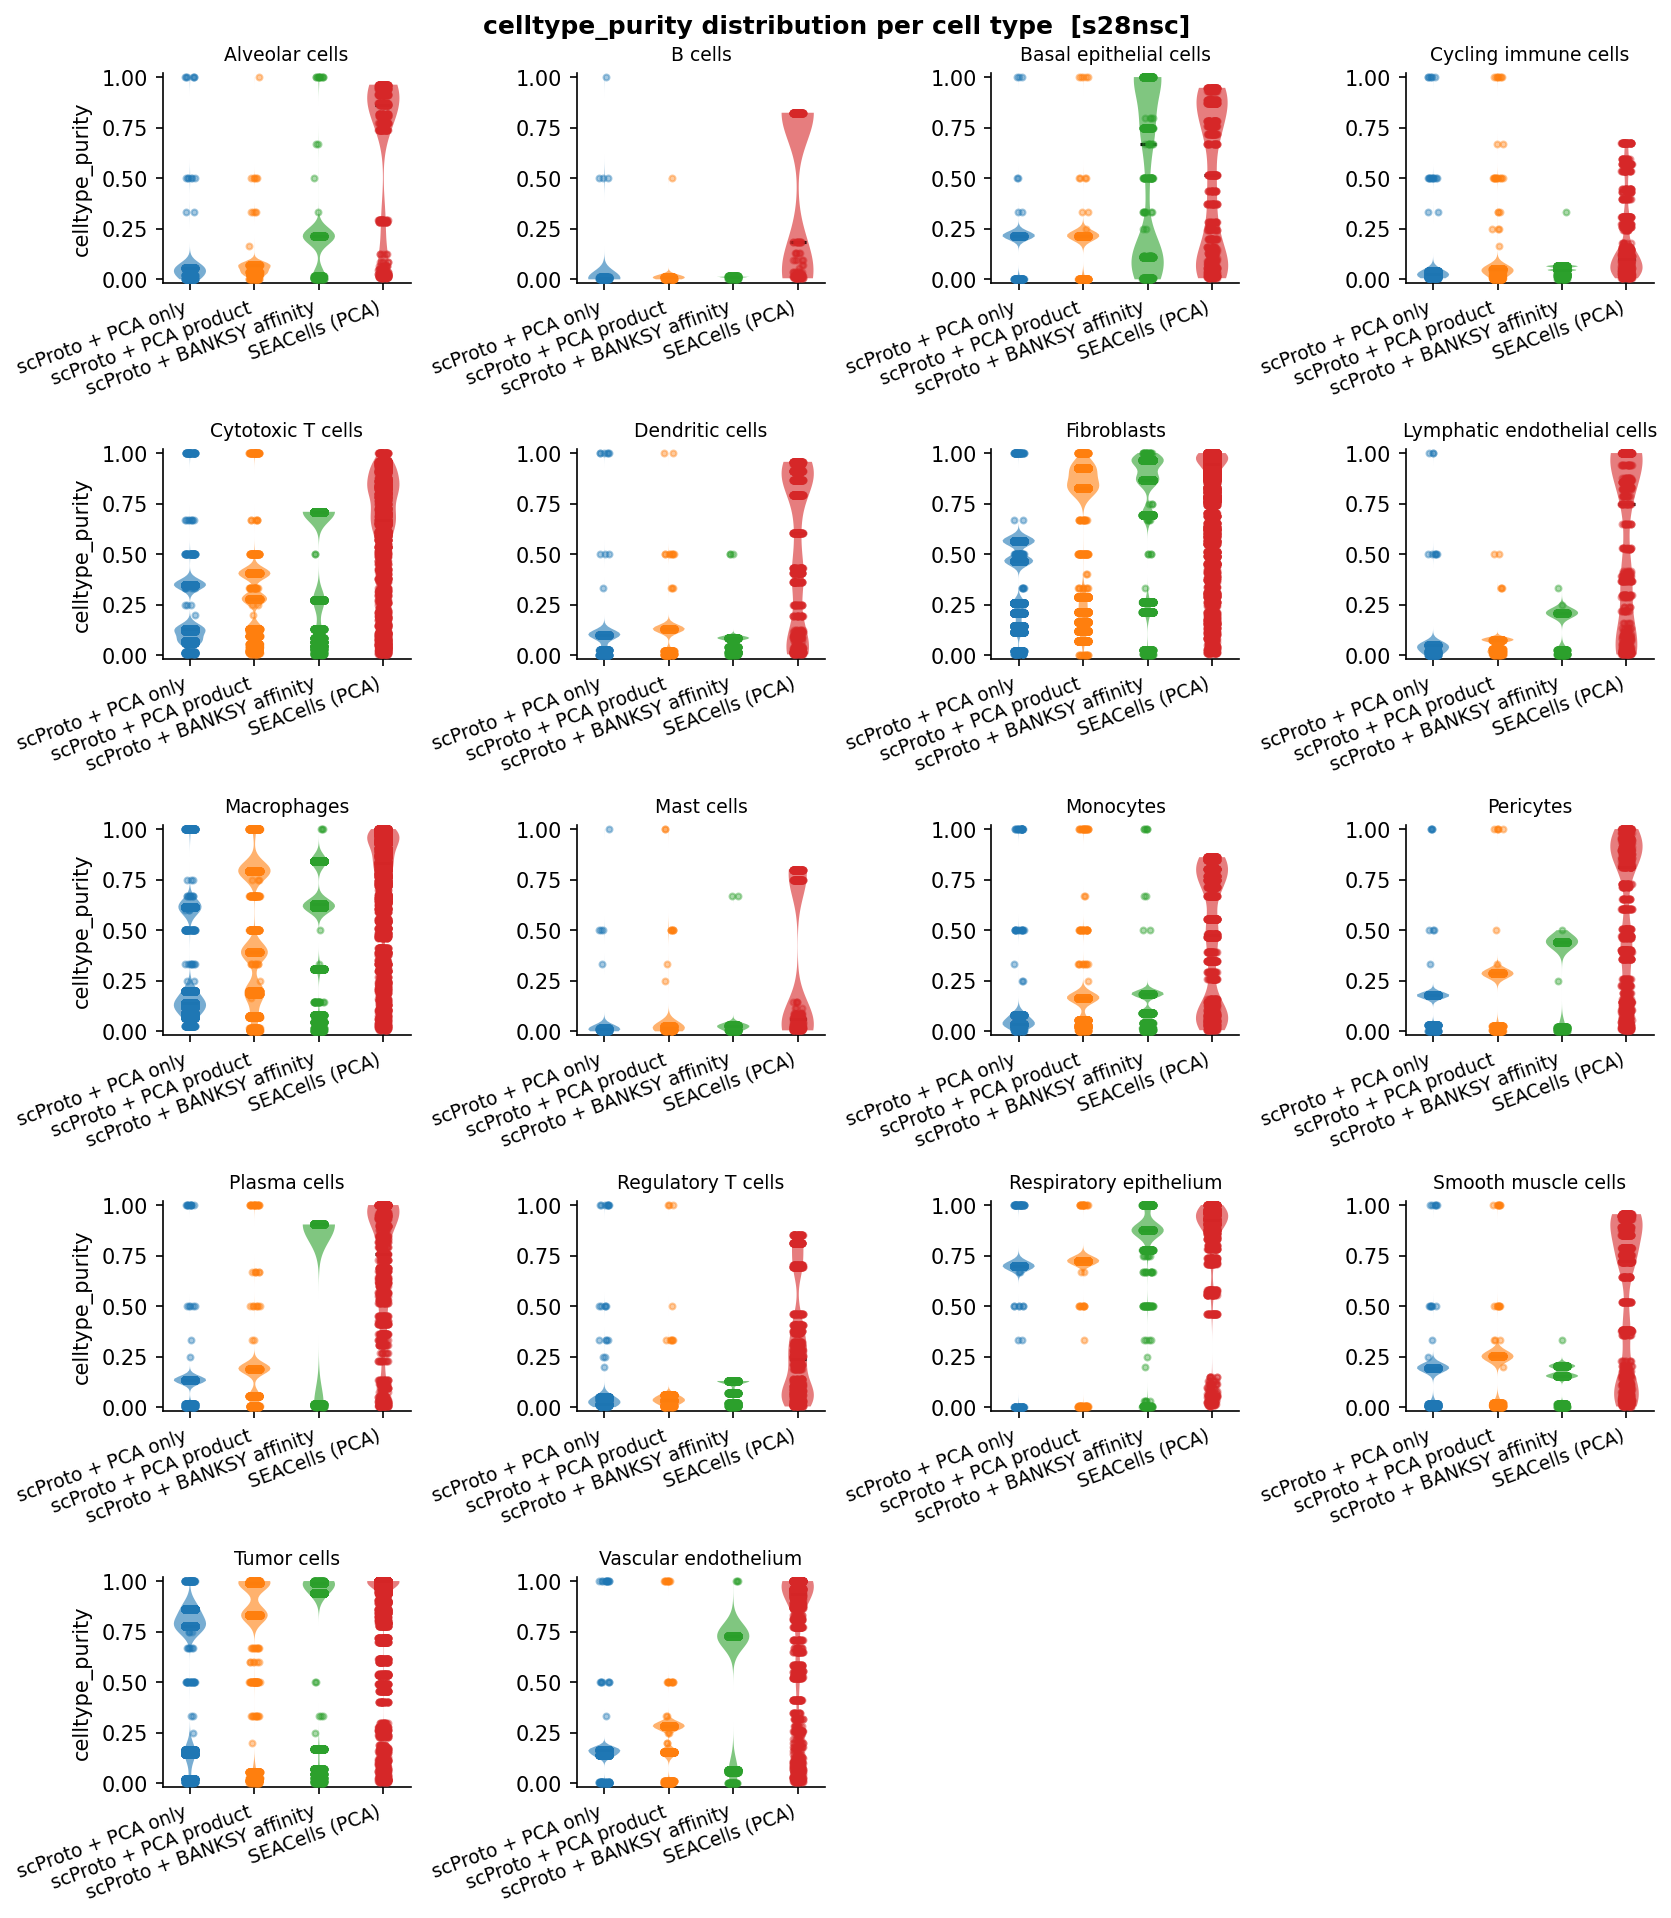

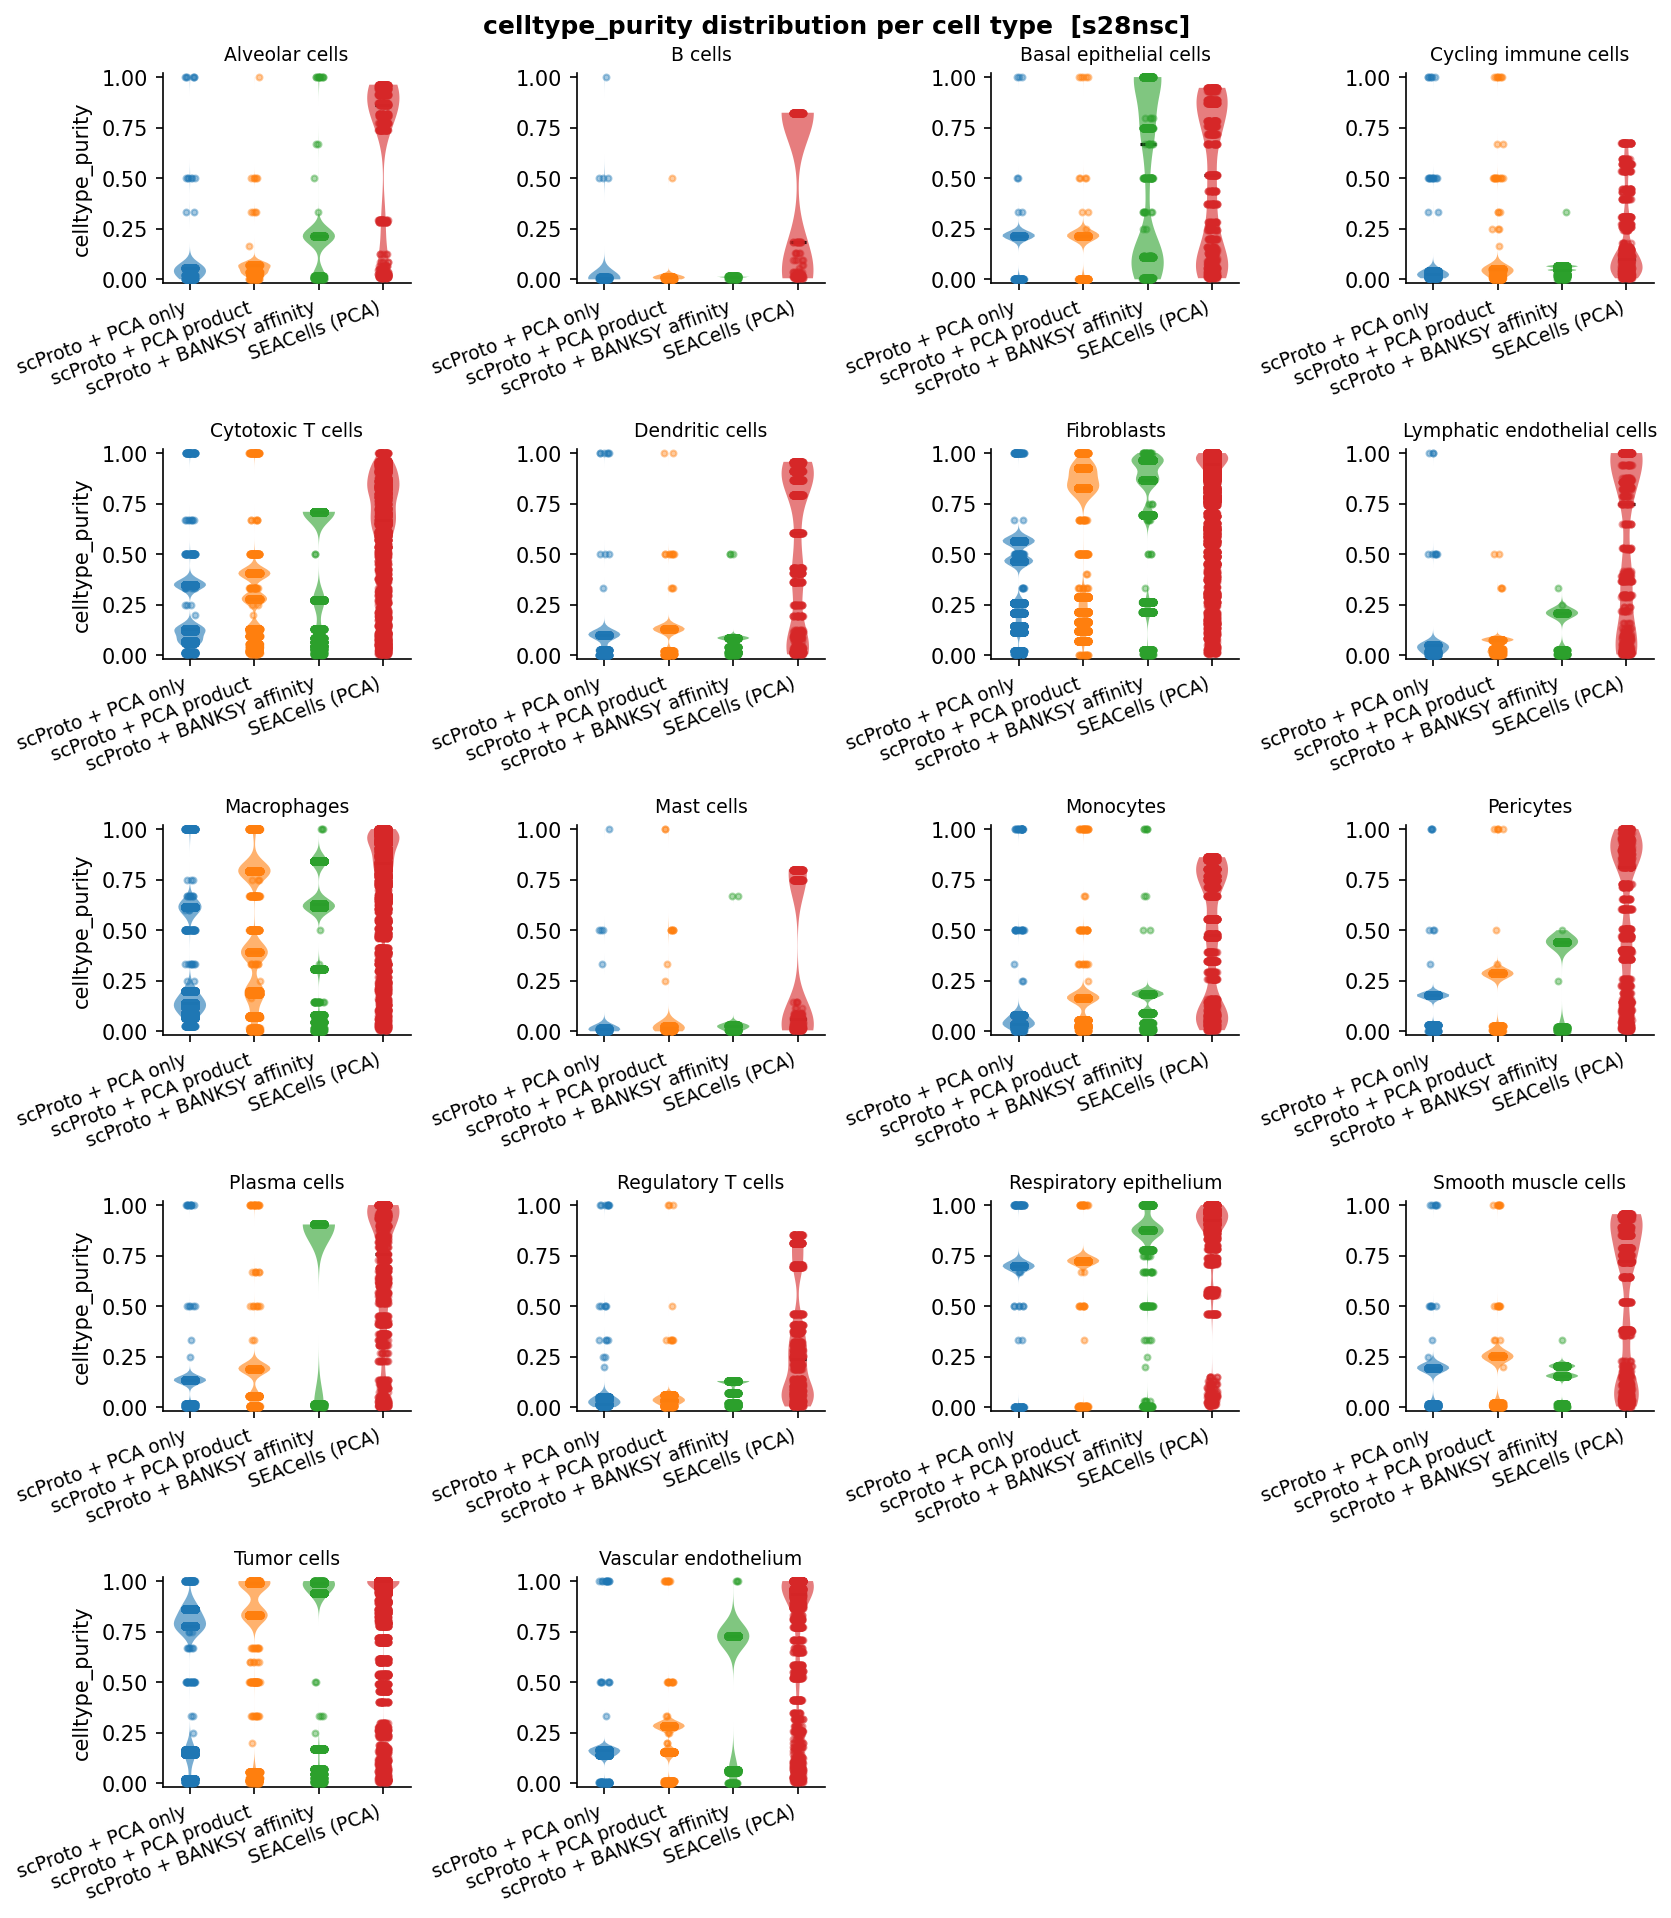

In [ ]:
fig_purity_violin(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='celltype_purity',
    save_path=os.path.join(GRAPH_DIR, 'spatial_celltype_purity_violin.pdf'),
)

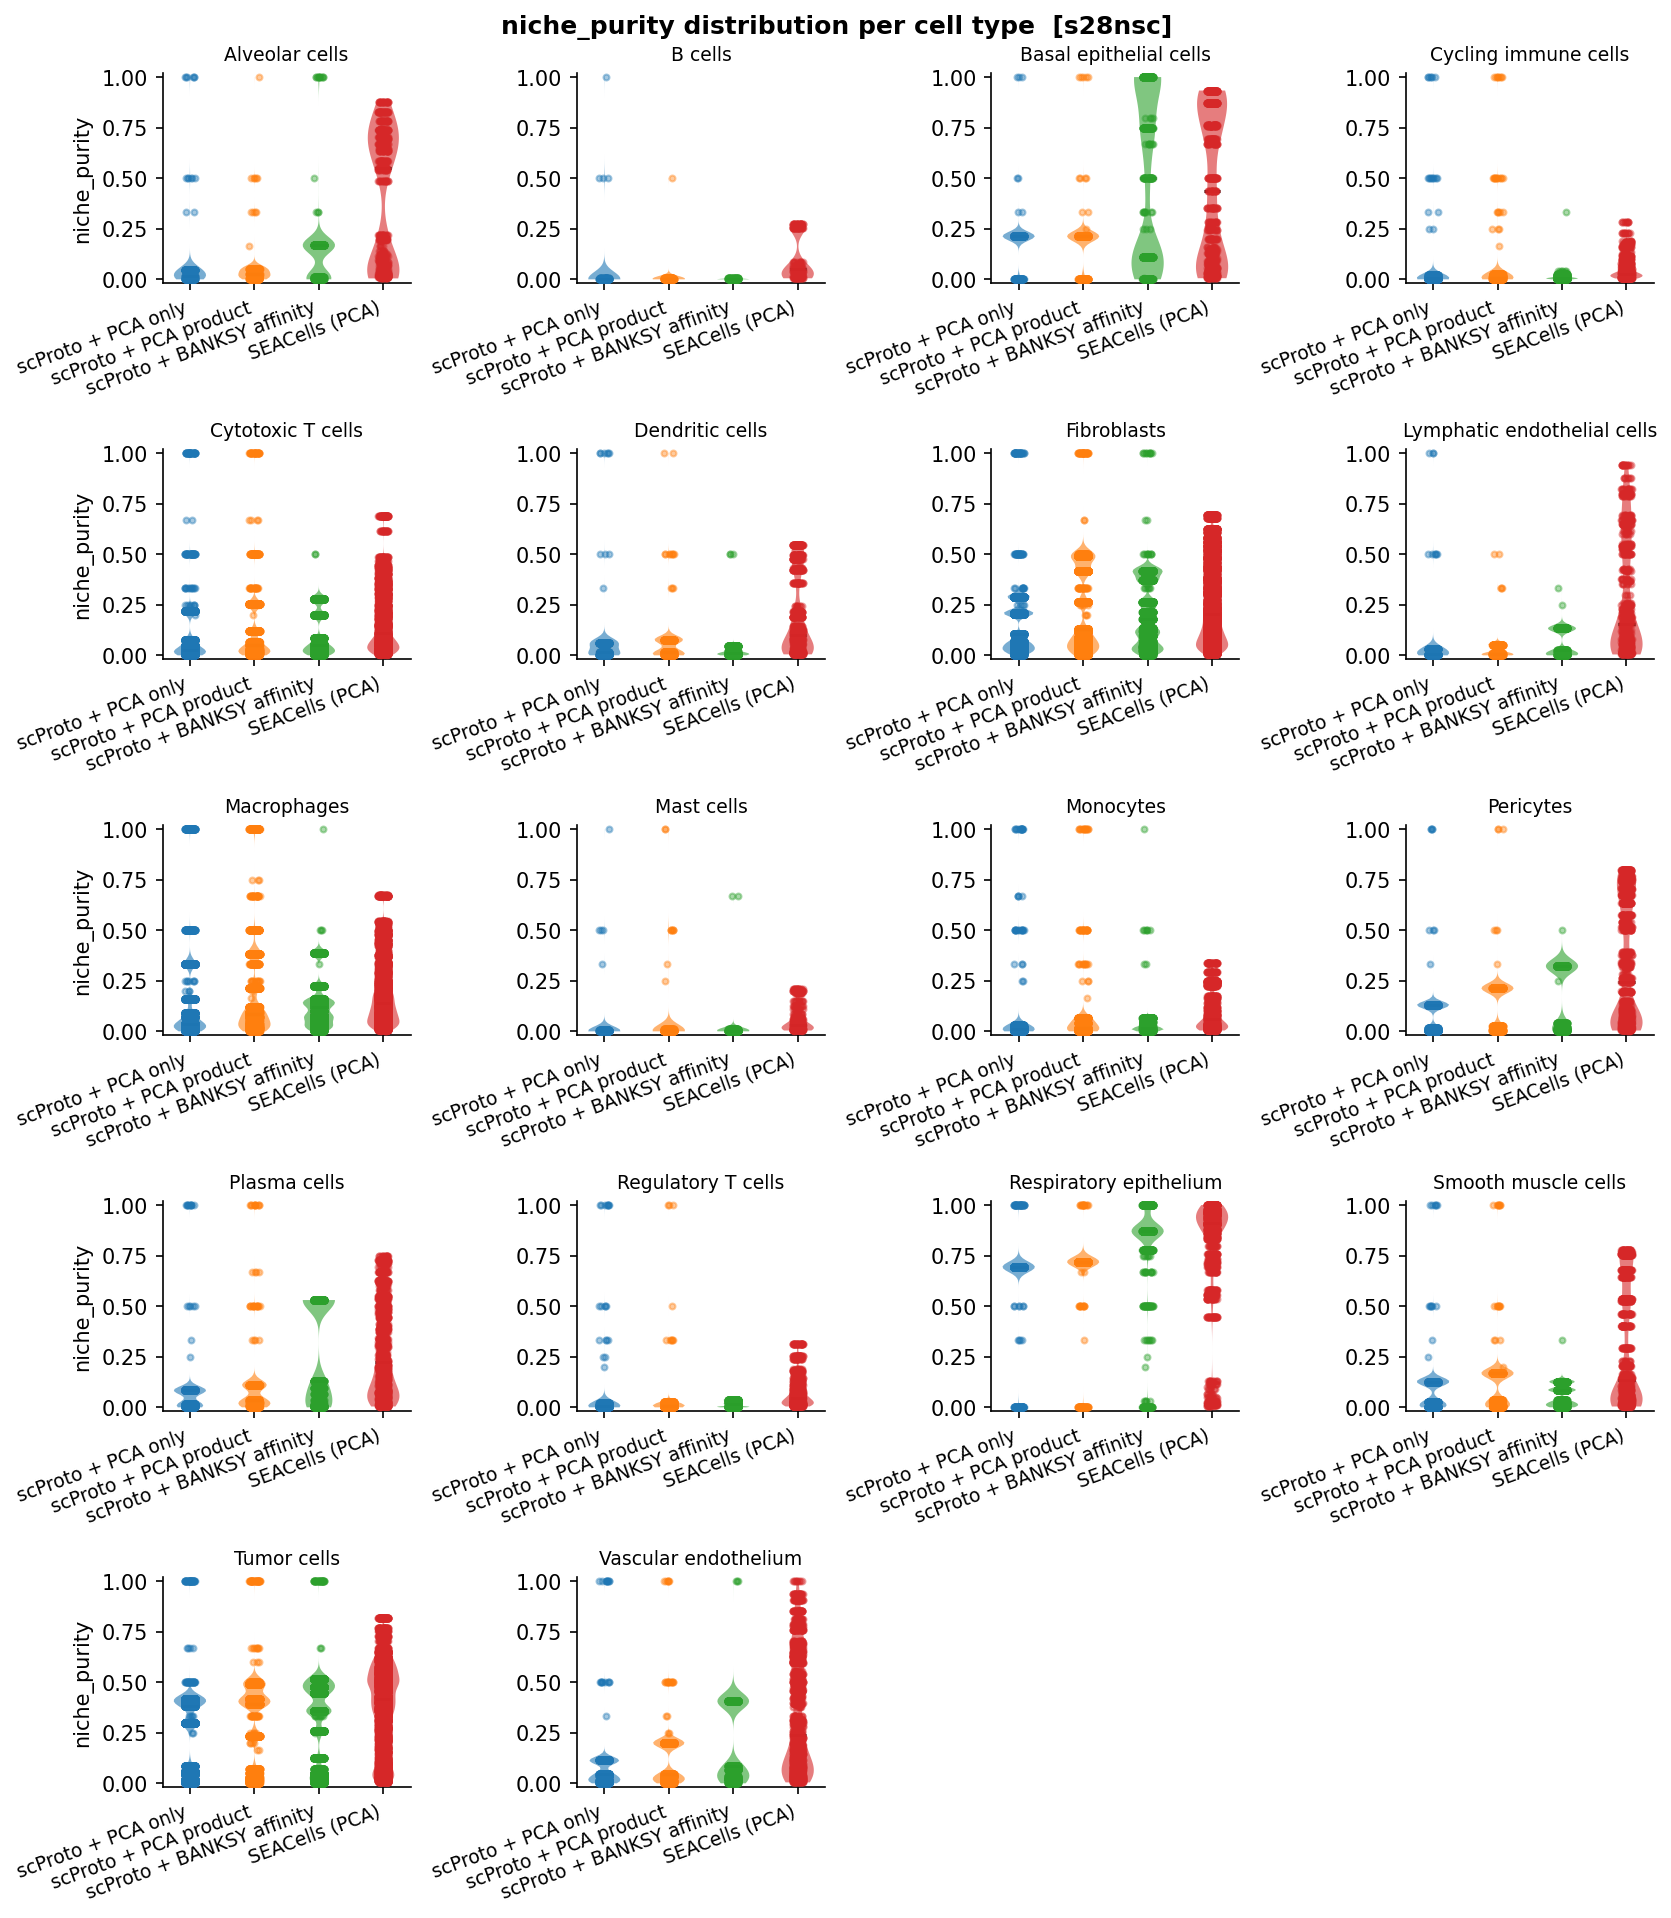

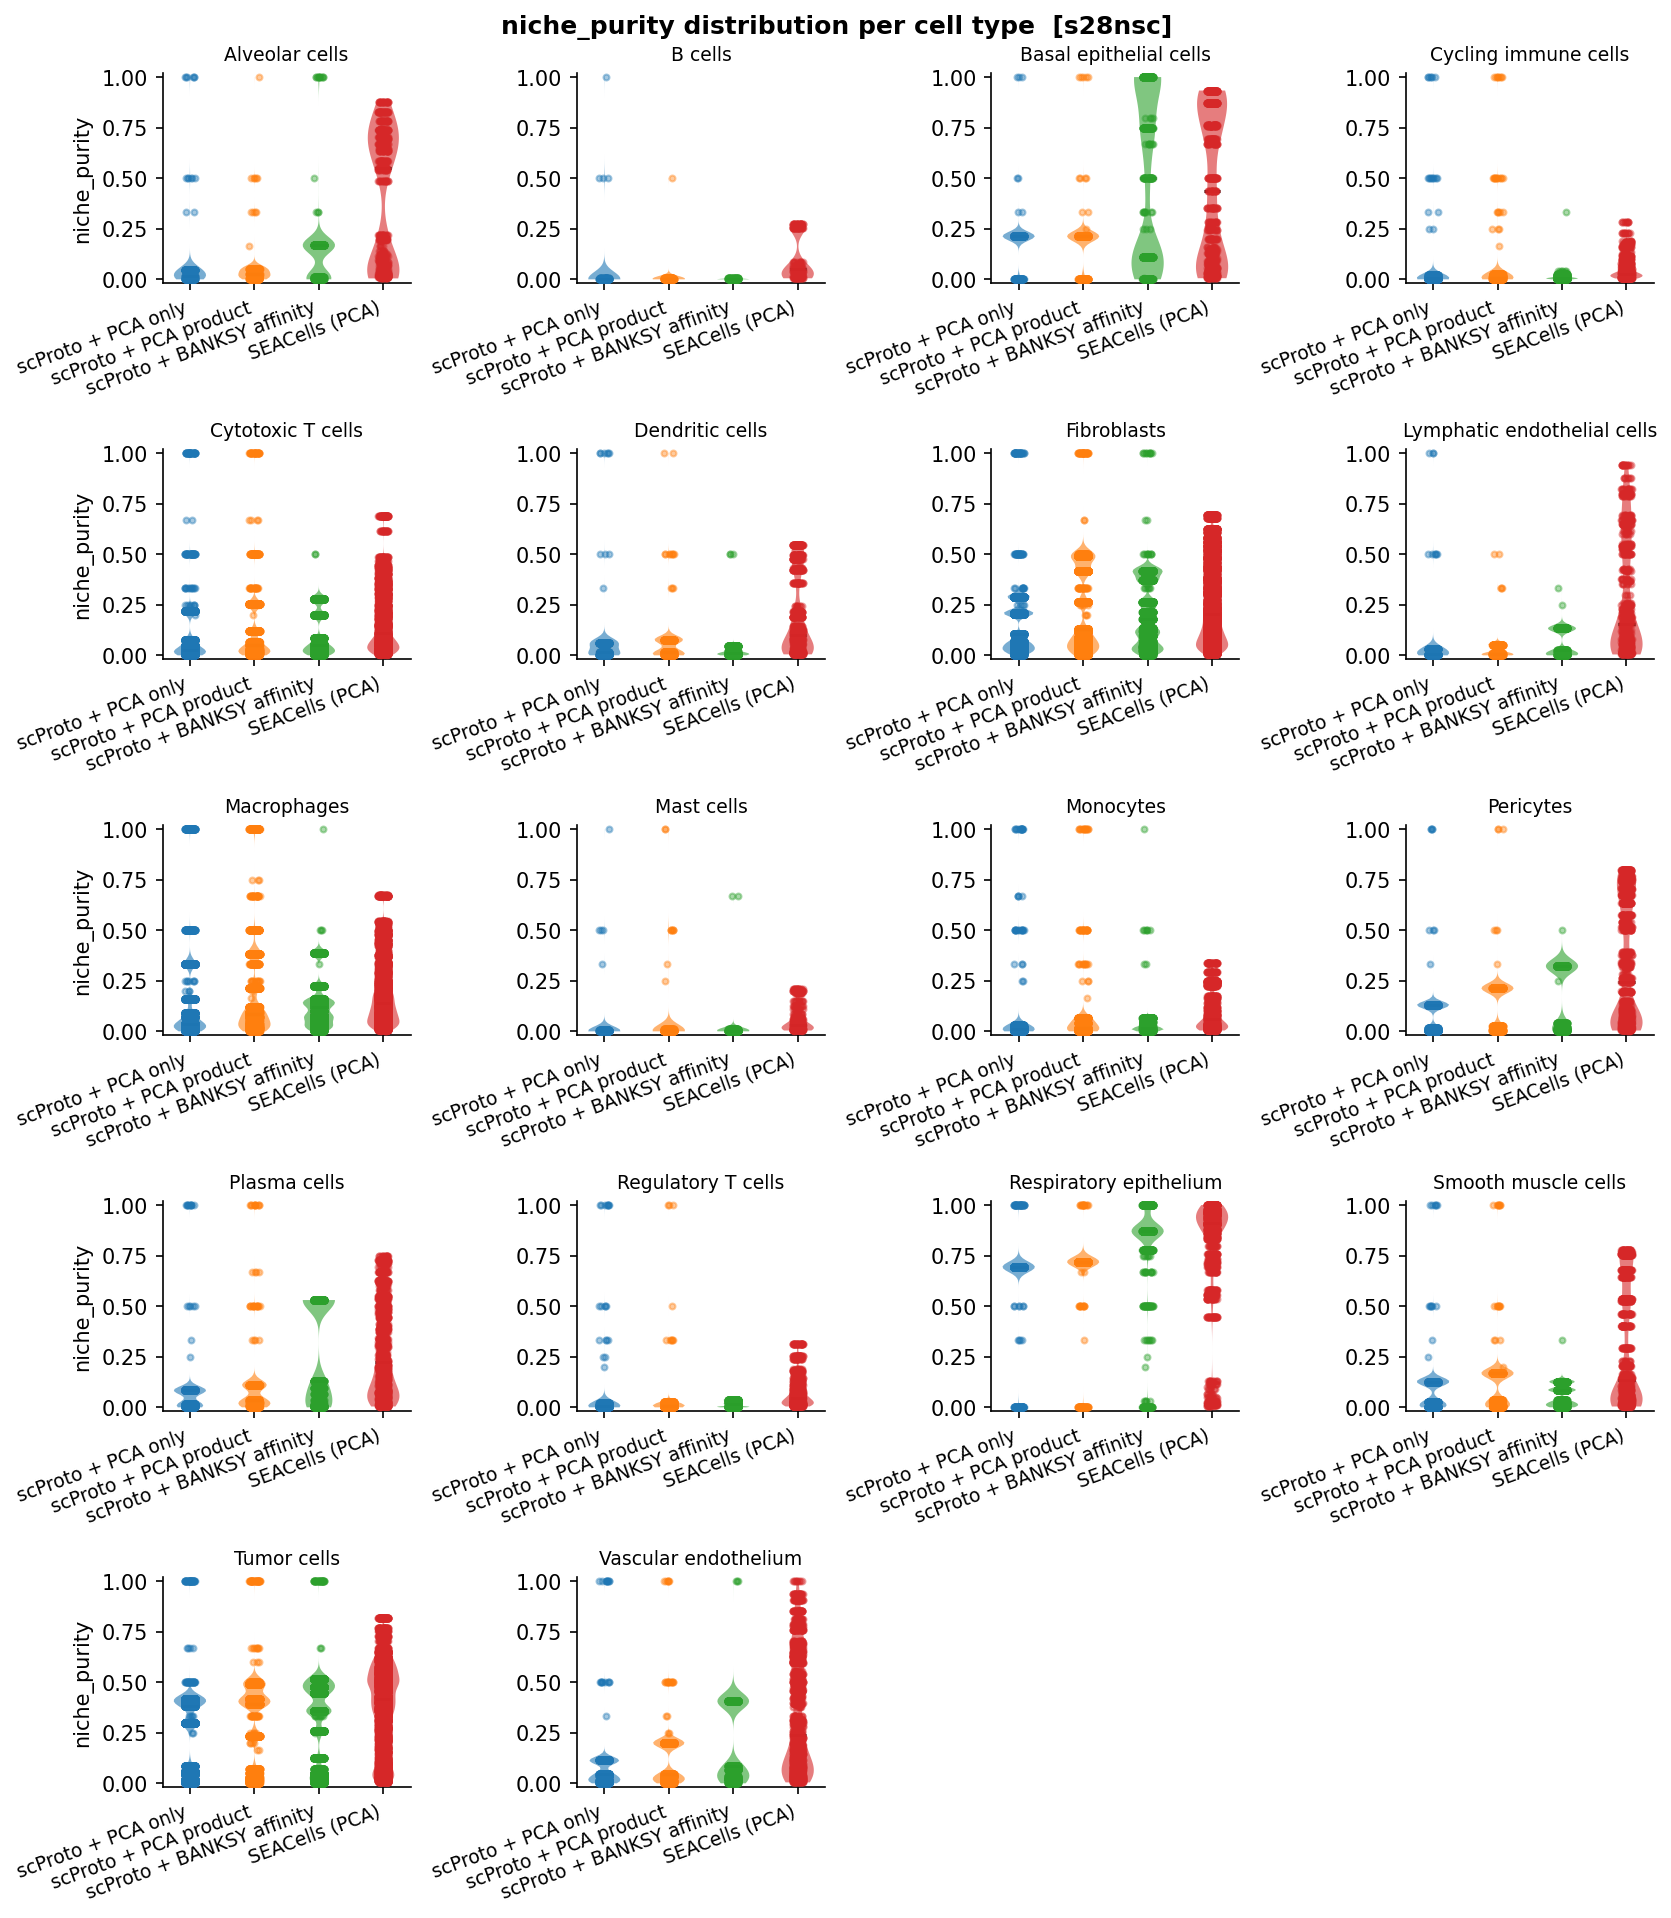

In [ ]:
fig_purity_violin(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='niche_purity',
    save_path=os.path.join(GRAPH_DIR, 'spatial_niche_purity_violin.pdf'),
)